In [21]:
# Imports necesarios para el notebook
import random

from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import scipy as sp
from greedy import greedy_monedas

from util import time_algorithm

# Siempre seteamos la seed de aleatoridad para que los # resultados sean reproducibles
random.seed(12345)
np.random.seed(12345)

sns.set_theme()

In [22]:
x = np.linspace(100, 1_000_000, 20).astype(int)

def get_random_cant_monedas(s):
    # devuelve un array aleatorio de numeros mayores a 0 
    return [random.randint(1, 50) for _ in range(s)]

results = time_algorithm(greedy_monedas, x, lambda s: [get_random_cant_monedas(s)])

print(results)

{np.int64(100): 0.00010011196136474609, np.int64(52726): 0.01422121524810791, np.int64(105352): 0.02775607109069824, np.int64(157978): 0.0415229082107544, np.int64(210605): 0.05694591999053955, np.int64(263231): 0.0707627773284912, np.int64(315857): 0.08601775169372558, np.int64(368484): 0.10966169834136963, np.int64(421110): 0.10763568878173828, np.int64(473736): 0.1255956172943115, np.int64(526363): 0.13398427963256837, np.int64(578989): 0.1641383409500122, np.int64(631615): 0.18042590618133544, np.int64(684242): 0.1756807327270508, np.int64(736868): 0.204744553565979, np.int64(789494): 0.20794181823730468, np.int64(842121): 0.2349480390548706, np.int64(894747): 0.22493884563446045, np.int64(947373): 0.24052631855010986, np.int64(1000000): 0.2542052030563354}


Text(0, 0.5, 'Tiempo de ejecución (s)')

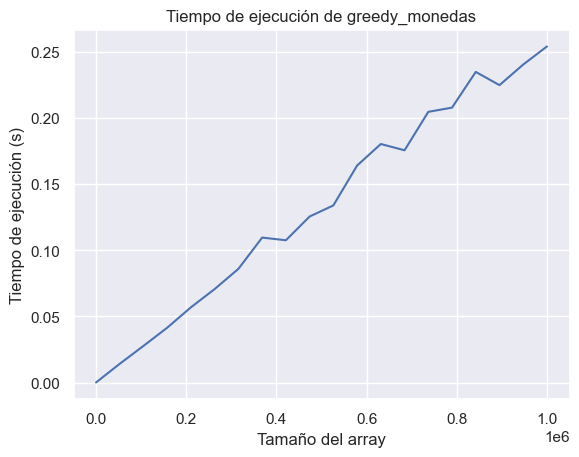

In [23]:
ax: plt.Axes
fig, ax = plt.subplots()
ax.plot(x, [results[i] for i in x], label="Medición")
ax.set_title('Tiempo de ejecución de greedy_monedas')
ax.set_xlabel('Tamaño del array')
ax.set_ylabel('Tiempo de ejecución (s)')


In [24]:
# scipy nos pide una función que recibe primero x y luego los parámetros a ajustar:
f = lambda x, c1, c2: c1 * x * np.log(x) + c2 

c, pcov = sp.optimize.curve_fit(f, x, [results[n] for n in x])

print(f"c_1 = {c[0]}, c_2 = {c[1]}")
r = np.sum((c[0] * x * np.log(x) + c[1] - [results[n] for n in x])**2)
print(f"Error cuadrático total: {r}")

c_1 = 1.8576649223396326e-08, c_2 = 0.009140947706900732
Error cuadrático total: 0.0013755313273152254


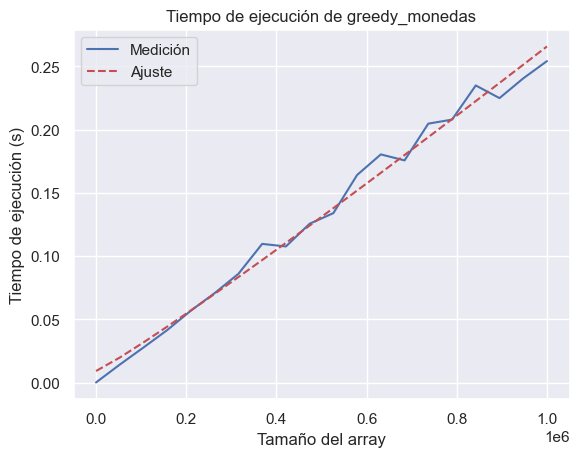

In [25]:
ax.plot(x, [c[0] * n * np.log(n) + c[1] for n in x], 'r--', label="Ajuste")
ax.legend()
fig

Text(0, 0.5, 'Error absoluto (s)')

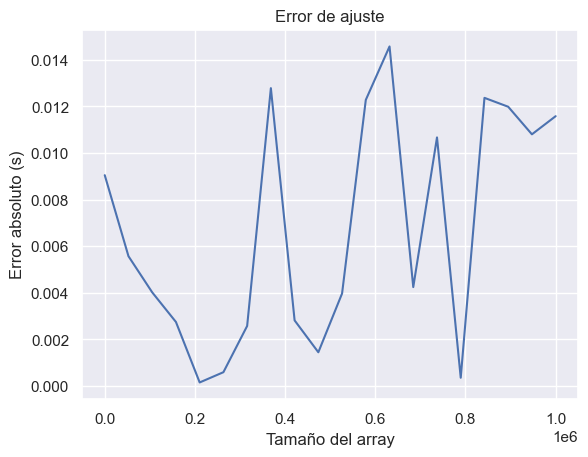

In [26]:
ax: plt.Axes
fig, ax = plt.subplots()
errors = [np.abs(c[0] * n * np.log(n) + c[1] - results[n]) for n in x]
ax.plot(x, errors)
ax.set_title('Error de ajuste')
ax.set_xlabel('Tamaño del array')
ax.set_ylabel('Error absoluto (s)')